In [3]:
import pandas   as pd
import numpy    as np
import joblib
import dill

from sklearn.preprocessing          import StandardScaler
from incdbscan.incrementaldbscan    import IncrementalDBSCAN
from sklearn.metrics                import accuracy_score, f1_score, classification_report

In [ ]:
pip install incdbscan

In [ ]:
pip install dill

In [12]:
# --- Định nghĩa cấu hình ---
METRICS = [
    'Velocity_Anomaly',
    'Value_Anomaly',
    'TimeGap_Anomaly',
    'Location_Anomaly',
    'Network_Anomaly'
]

EPS_VALUE = 0.5   # cố định eps

# --- Load dữ liệu lịch sử ---
data_history = pd.read_csv('data_history_min.csv')
X_history = data_history[METRICS].fillna(0)
y_true = data_history['is_fraud']  # Ground truth để đánh giá

# --- Scale dữ liệu ---
scaler = StandardScaler()
scaler.fit(X_history)

X_history_scaled = scaler.transform(X_history)

# --- Thử nhiều giá trị min_pts ---
from sklearn.metrics import accuracy_score, f1_score

min_pts_range = range(6, 11)

print("\n🔎 Đánh giá các giá trị min_pts từ 6 → 10\n")
results = []

for min_pts in min_pts_range:
    idbscan = IncrementalDBSCAN(eps=EPS_VALUE, min_pts=min_pts)
    idbscan.insert(X_history_scaled)

    labels = idbscan.get_cluster_labels(X_history_scaled)

    # DBSCAN đánh dấu anomaly = -1 → gán tạm thành 1
    y_pred = (labels == -1).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    num_clusters = len(set(labels) - {-1})

    print(f"min_pts = {min_pts} → Accuracy = {acc:.4f}, F1 = {f1:.4f}, Clusters = {num_clusters}")

    results.append((min_pts, acc, f1, num_clusters))

# --- Chọn min_pts tốt nhất theo F1 (ưu tiên fraud detection) ---
best = max(results, key=lambda x: x[2])
print(f"\n✅ Best min_pts theo F1: {best[0]} (Acc={best[1]:.4f}, F1={best[2]:.4f}, Clusters={best[3]})")



🔎 Đánh giá các giá trị min_pts từ 6 → 10

min_pts = 6 → Accuracy = 0.7965, F1 = 0.3061, Clusters = 8
min_pts = 7 → Accuracy = 0.7699, F1 = 0.2806, Clusters = 3
min_pts = 8 → Accuracy = 0.7469, F1 = 0.2618, Clusters = 4
min_pts = 9 → Accuracy = 0.7212, F1 = 0.2436, Clusters = 4
min_pts = 10 → Accuracy = 0.6991, F1 = 0.2298, Clusters = 5

✅ Best min_pts theo F1: 6 (Acc=0.7965, F1=0.3061, Clusters=8)


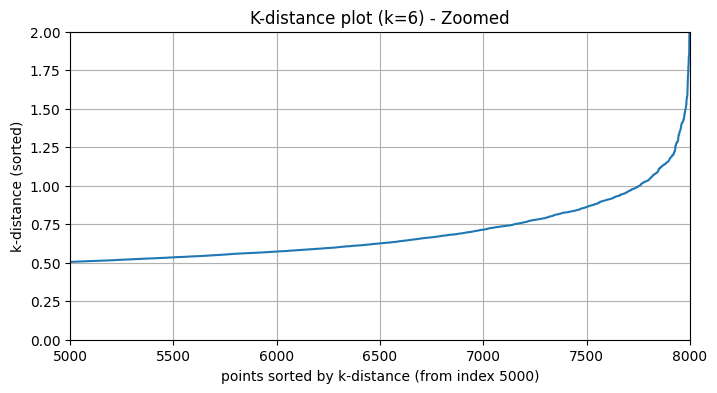

In [28]:
# K-distance plot để chọn eps (visual)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# params
min_pts = 6   # <-- sửa nếu bạn dùng min_pts khác
X = X_history_scaled  # dữ liệu đã scale

# compute k-distance (k = min_pts)
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(X)
distances, indices = nbrs.kneighbors(X)
k_dist = np.sort(distances[:, -1])

# Zoom range
start_idx = 5000  # bắt đầu zoom từ điểm 30000

plt.figure(figsize=(8,4))
plt.plot(range(start_idx, len(k_dist)), k_dist[start_idx:])

plt.title(f'K-distance plot (k={min_pts}) - Zoomed')
plt.ylabel('k-distance (sorted)')
plt.xlabel(f'points sorted by k-distance (from index {start_idx})')

plt.xlim(start_idx, len(k_dist)) # zoom trục X
plt.ylim(0,2)
plt.grid(True)
plt.show()

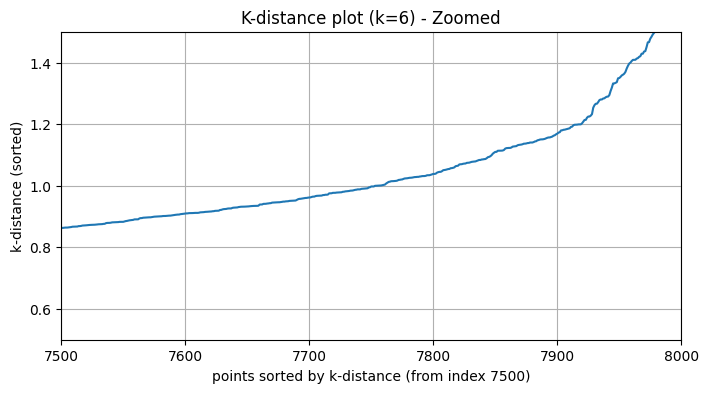

In [32]:
# K-distance plot để chọn eps (visual)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# params
min_pts = 6   # <-- sửa nếu bạn dùng min_pts khác
X = X_history_scaled  # dữ liệu đã scale

# compute k-distance (k = min_pts)
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(X)
distances, indices = nbrs.kneighbors(X)
k_dist = np.sort(distances[:, -1])

# Zoom range
start_idx = 7500  # bắt đầu zoom từ điểm 30000

plt.figure(figsize=(8,4))
plt.plot(range(start_idx, len(k_dist)), k_dist[start_idx:])

plt.title(f'K-distance plot (k={min_pts}) - Zoomed')
plt.ylabel('k-distance (sorted)')
plt.xlabel(f'points sorted by k-distance (from index {start_idx})')

plt.xlim(start_idx, len(k_dist)) # zoom trục X
plt.ylim(0.5,1.5)

plt.grid(True)
plt.show()

In [27]:
import sys
sys.setrecursionlimit(10000)
# --- Định nghĩa cấu hình ---
METRICS = [
    'Velocity_Anomaly',
    'Value_Anomaly',
    'TimeGap_Anomaly',
    'Location_Anomaly',
    'Network_Anomaly'
]
EPS_VALUE = 0.7
MIN_SAMPLES_VALUE = 6
MODEL_FILENAME = 'model.pkl'
SCALER_FILENAME = 'scaler.pkl'

# --- Load dữ liệu lịch sử ---
data_history = pd.read_csv('data_history_min.csv')
X_history = data_history[METRICS].fillna(0)

# --- Tạo, Huấn luyện (fit) và Lưu Standard Scaler ---
scaler = StandardScaler()
scaler.fit(X_history)
joblib.dump(scaler, SCALER_FILENAME)
print(f"✅ Scaler đã lưu vào '{SCALER_FILENAME}'")

# --- Scale dữ liệu lịch sử ---
X_history_scaled = scaler.transform(X_history)

# --- Huấn luyện IncrementalDBSCAN ---
idbscan_model = IncrementalDBSCAN(eps=EPS_VALUE, min_pts=MIN_SAMPLES_VALUE)
idbscan_model.insert(X_history_scaled)  # insert batch history

# --- Lấy nhãn cluster cho toàn bộ dữ liệu lịch sử ---
labels = idbscan_model.get_cluster_labels(X_history_scaled)
num_clusters = len(set(labels) - {-1})  # loại bỏ noise (-1)
print(f"Huấn luyện history hoàn tất. Số cụm: {num_clusters}")

# --- Thêm cột nhãn cluster và cột anomaly vào data_history ---
data_history_results = data_history.copy()
data_history_results['cluster_label'] = labels
data_history_results['is_anomaly'] = data_history_results['cluster_label'] == -1

# --- In các điểm bất thường ---
anomaly_history = data_history_results[data_history_results['is_anomaly']]
if not anomaly_history.empty:
    print(f"\n💡 Phát hiện {len(anomaly_history)} điểm ANOMALY (label = -1) trong dữ liệu lịch sử:")
y_true = data_history['is_fraud'].astype(int)           # nhãn thật
y_pred = (data_history_results['is_anomaly']).astype(int)  # anomaly = 1
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, zero_division=1)

print("\n📊 Hiệu suất mô hình trên dữ liệu lịch sử:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}") 

✅ Scaler đã lưu vào 'scaler.pkl'
Huấn luyện history hoàn tất. Số cụm: 6

💡 Phát hiện 615 điểm ANOMALY (label = -1) trong dữ liệu lịch sử:

📊 Hiệu suất mô hình trên dữ liệu lịch sử:
Accuracy: 0.9407
F1-score: 0.5133
